In [1]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [2]:
X_train.shape

(55000, 28, 28)

In [3]:
y_train.shape

(55000,)

In [4]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [5]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [6]:
class_names[y_train[0]]

'Ankle boot'

In [7]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [17]:
model.layers[1].name


'dense'

In [19]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [20]:
model.get_layer('dense') is hidden1

True

In [21]:
weights, biases = hidden1.get_weights()
weights

array([[ 0.00410639,  0.06186883,  0.00537102, ...,  0.05931792,
        -0.03918251, -0.05954945],
       [ 0.03523824, -0.05579007,  0.03950603, ..., -0.0184512 ,
         0.00049281, -0.03614349],
       [-0.03053726,  0.00600125, -0.00797299, ..., -0.04395077,
         0.07323816,  0.03297088],
       ...,
       [-0.05007403, -0.02029865, -0.00200732, ..., -0.06358932,
         0.0290096 ,  0.01222873],
       [ 0.01402477, -0.04950736,  0.01796671, ..., -0.0292842 ,
         0.0029754 , -0.02023091],
       [ 0.02709071,  0.06238526,  0.06911485, ...,  0.03295895,
        -0.03044385, -0.06125149]], shape=(784, 300), dtype=float32)

In [24]:
weights.shape

(784, 300)

In [25]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [26]:
biases.shape

(300,)

In [27]:
model.compile(loss="sparse_categorical_crossentropy",
optimizer="sgd",
metrics=["accuracy"])

In [28]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7660 - loss: 0.7082 - val_accuracy: 0.8274 - val_loss: 0.4980
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8328 - loss: 0.4817 - val_accuracy: 0.8376 - val_loss: 0.4498
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8483 - loss: 0.4371 - val_accuracy: 0.8460 - val_loss: 0.4284
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8562 - loss: 0.4102 - val_accuracy: 0.8508 - val_loss: 0.4150
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8630 - loss: 0.3903 - val_accuracy: 0.8560 - val_loss: 0.4045
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8687 - loss: 0.3747 - val_accuracy: 0.8578 - val_loss: 0.3963
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8724 - loss: 0.3616 - val_accuracy: 0.8598 - val_loss: 0.3893
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8761 - loss: 0.3503 - 

In [32]:
history.history

{'accuracy': [0.765999972820282,
  0.8327999711036682,
  0.8483454585075378,
  0.8562363386154175,
  0.8629817962646484,
  0.8687090873718262,
  0.8723636269569397,
  0.8760545253753662,
  0.8795090913772583,
  0.8826545476913452,
  0.8853636384010315,
  0.8880727291107178,
  0.8899090886116028,
  0.8925091028213501,
  0.8944727182388306,
  0.8967636227607727,
  0.8988181948661804,
  0.9006181955337524,
  0.9026727080345154,
  0.9048181772232056,
  0.9066181778907776,
  0.9084545373916626,
  0.9097999930381775,
  0.9117454290390015,
  0.9132545590400696,
  0.9148908853530884,
  0.9165818095207214,
  0.9172182083129883,
  0.9186000227928162,
  0.9202181696891785],
 'loss': [0.7082288861274719,
  0.48172202706336975,
  0.43709126114845276,
  0.41017094254493713,
  0.3903317153453827,
  0.3746870458126068,
  0.3616260290145874,
  0.3503298759460449,
  0.3403403162956238,
  0.3313746154308319,
  0.32312464714050293,
  0.31540563702583313,
  0.30829596519470215,
  0.3015470504760742,
  0.29

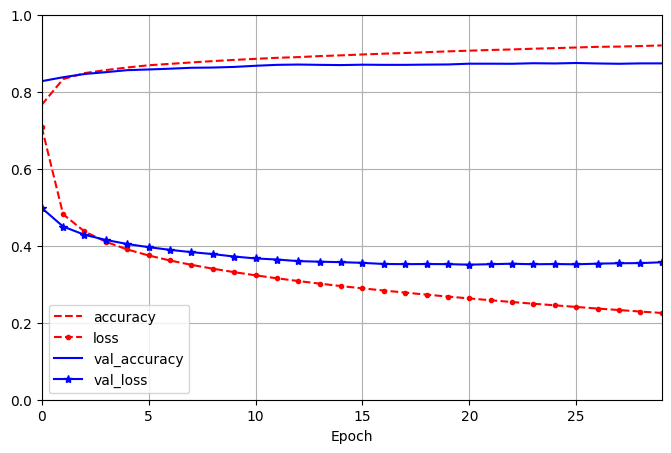

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"])
plt.show()